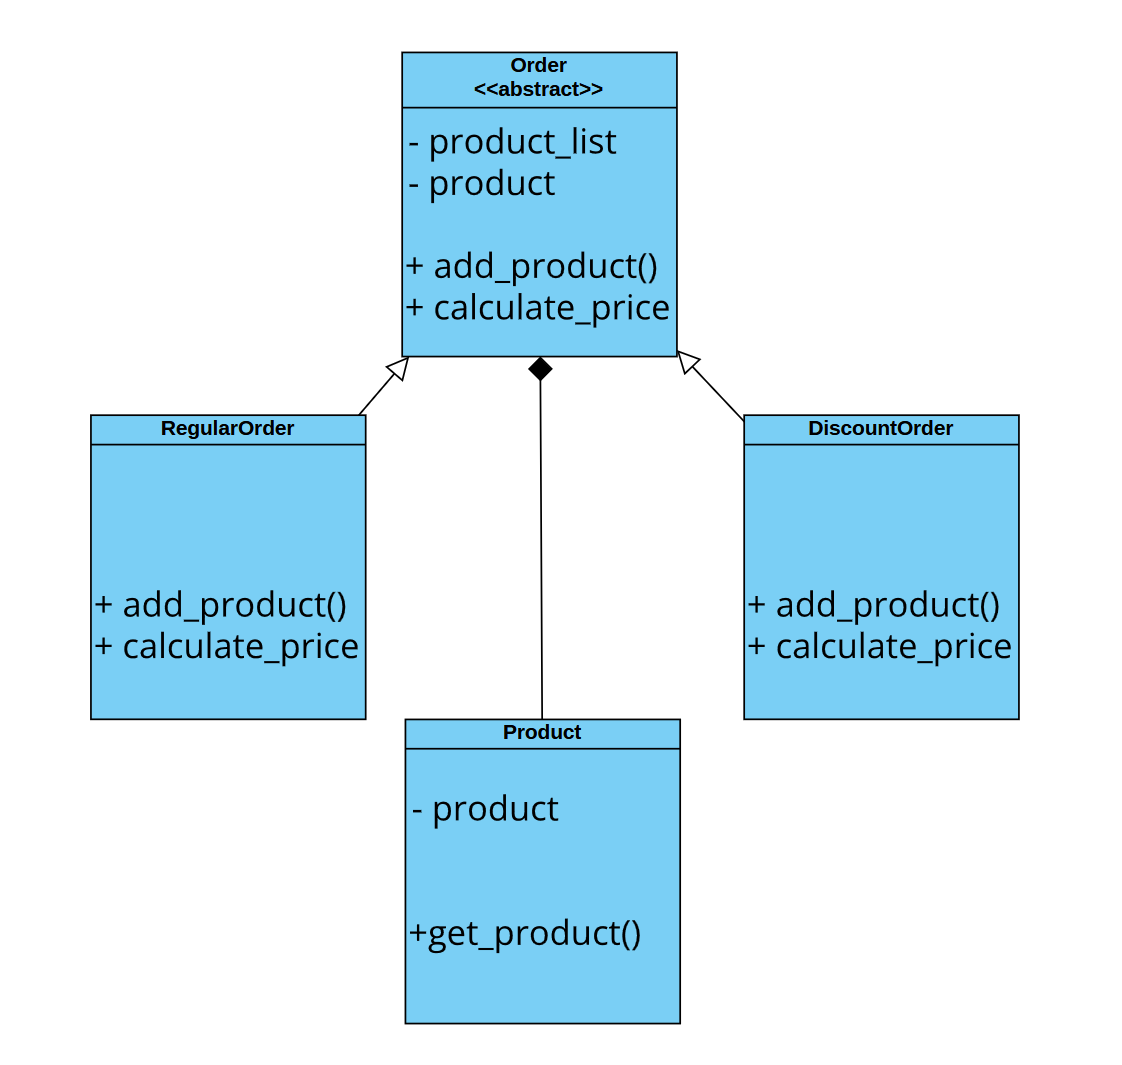

In [29]:
# Создать обычный заказ из 3 товаров и дисконтный заказ из 2 товаров.
# Рассчитать стоимость доставки для каждого обоими способами.
# Вывести итоговую цену (товары + доставка).
from abc import ABC, abstractmethod

class Order(ABC):

    def __init__(self) -> None:
        self.product_list = []
        self.product = Product()

    @abstractmethod
    def add_product(self, id: int, quantity: int) -> None:
        pass

    @abstractmethod
    def calculate_price_and_delivery(self, delivery: str) -> str:
        pass

class RegularOrder(Order):

    def __init__(self) -> None:
        super().__init__()

    def add_product(self, id: int, quantity: int) -> None:
        item = self.product.get_product(id, quantity)
        if item == False:
            print ('Нет в наличии')
        else:
            self.product_list.append(item)

    def calculate_price_and_delivery(self, delivery: str) -> str:
        price = 0
        if delivery == 'pickup':
            for product in self.product_list:
                price += product['Price'] * product['Quantity']
            print(self.product_list)
            return f'Стоимость обычного заказа с самовывозом: {price} р'
        elif delivery == 'courier':
            for product in self.product_list:
                price += product['Price'] * product['Quantity']
            print(self.product_list)
            return f'Стоимость обычного заказа с доставкой курьером: {price + 20} р'
        else:
            return 'Неверный ввод'

class DiscountOrder(Order):

    def __init__(self) -> None:
        super().__init__()

    def add_product(self, id: int, quantity: int) -> None:
        item = self.product.get_product(id, quantity)
        if item == False:
            print ('Нет в наличии')
        else:
            self.product_list.append(item)

    def calculate_price_and_delivery(self, delivery: str) -> str:
        price = 0
        if delivery == 'pickup':
            for product in self.product_list:
                price += product['Price'] * product['Quantity']
            print(self.product_list)
            return f'Стоимость дисконтного заказа с самовывозом: {price - (price * 0.1)} р'
        elif delivery == 'courier':
            for product in self.product_list:
                price += product['Price'] * product['Quantity']
            print(self.product_list)
            return f'Стоимость дисконтного заказа с доставкой курьером: {price - (price * 0.1) + 20} р'
        else:
            return 'Неверный ввод'

class Product:

    def __init__(self) -> None:
        self.product = [{'ID': 1, 'Name': 'гречка', 'Price': 10, 'Quantity': 2},
                        {'ID': 2, 'Name': 'картошка', 'Price': 20, 'Quantity': 1},
                        {'ID': 3, 'Name': 'масло', 'Price': 15, 'Quantity': 4},
                        {'ID': 4, 'Name': 'кефир', 'Price': 5, 'Quantity': 8},
                        {'ID': 5, 'Name': 'молоко', 'Price': 17, 'Quantity': 11}]

    def get_product(self, id: int, quantity: int) -> dict[str, int | str] | bool | None:
        for product in self.product:
            if product['ID'] == id:
                if product['Quantity'] >= quantity:
                    product['Quantity'] -= quantity
                    return {'Name': product['Name'], 'Price': product['Price'], 'Quantity': quantity}
                else:
                    return False
            else:
                continue

ord1 = RegularOrder()
ord1.add_product(1, 3)
ord1.add_product(2, 1)
ord1.add_product(4, 4)
ord1.add_product(5, 3)
ord1.calculate_price_and_delivery('pickup')

Нет в наличии
[{'Name': 'картошка', 'Price': 20, 'Quantity': 1}, {'Name': 'кефир', 'Price': 5, 'Quantity': 4}, {'Name': 'молоко', 'Price': 17, 'Quantity': 3}]


'Стоимость обычного заказа с самовывозом: 91 р'

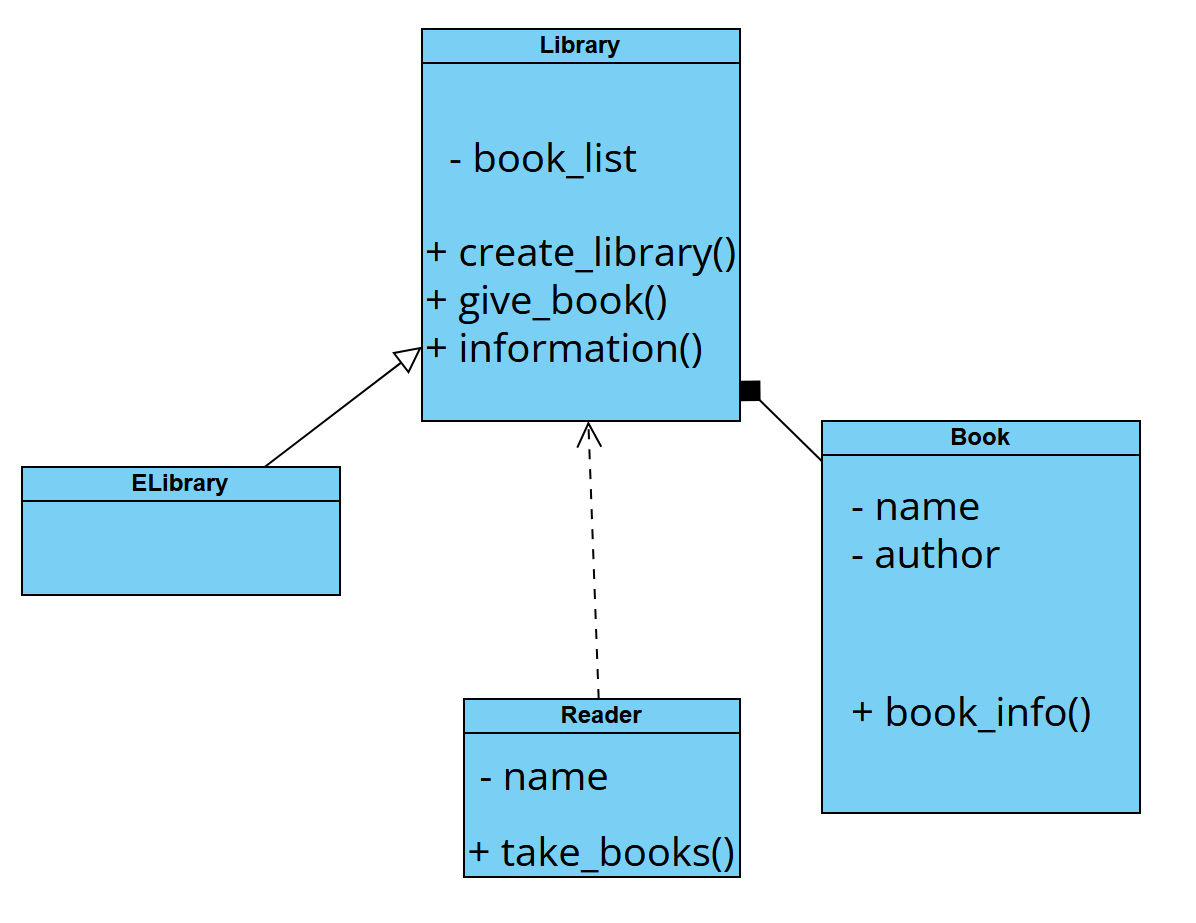

In [46]:
# Создать библиотеку, 2 читателей, 4 книги.
# Один читатель берет 2 книги, другой — 1.
# Электронная библиотека выдает 2 электронные книги.
# Вывести информацию о библиотеках.
class Library:

    def __init__(self) -> None:
        self.book_list: list[dict[str, str]] = []

    def create_library(self, book1: 'Book', book2: 'Book', book3: 'Book') -> None:
        self.book_list.append(book1.book_info())
        self.book_list.append(book2.book_info())
        self.book_list.append(book3.book_info())
        print(self.book_list)

    def give_book(self, books: list[str]) -> list[dict[str, str]]:
        order: list[dict[str, str]] = []
        for name in books:
            for book in self.book_list:
                if book['Name'] == name or book['Author'] == name:
                    order.append(book)
                    self.book_list.remove(book)
                    break
        return order

    def information(self) -> str:
        return f'Книги в библиотеке: {self.book_list}'

class ELibrary(Library):

    def __init__(self) -> None:
        super().__init__()

class Reader:

    def __init__(self, name: str) -> None:
        self.name: str = name

    def take_books(self, library: Library, books: list[str]) -> str:
        order = library.give_book(books)
        return f'Книги читателя {self.name}: {order}'

class Book:

    def __init__(self, name: str, author: str) -> None:
        self.name: str = name
        self.author: str = author

    def book_info(self) -> dict[str, str]:
        return {'Name': self.name, 'Author': self.author}

lib = Library()
elib = ELibrary()

book1 = Book('1984', 'Джордж Оруэлл')
book2 = Book('Мастер и Маргарита', 'Михаил Булгаков')
book3 = Book('Преступление и наказание', 'Фёдор Достоевский')
book4 = Book('Гарри Поттер', 'Джоан Роулинг')
book5 = Book('Шерлок Холмс', 'Артур Конан Дойл')
book6 = Book('Война и мир', 'Лев Толстой')

lib.create_library(book1, book2, book3)
elib.create_library(book4, book5, book6)

reader1 = Reader('Олег')
reader2 = Reader('Саша')

print(reader1.take_books(lib, ['1984', 'Фёдор Достоевский']))
print(reader2.take_books(elib, ['Гарри Поттер', 'Война и мир']))

print(lib.information())
print(elib.information())

[{'Name': '1984', 'Author': 'Джордж Оруэлл'}, {'Name': 'Мастер и Маргарита', 'Author': 'Михаил Булгаков'}, {'Name': 'Преступление и наказание', 'Author': 'Фёдор Достоевский'}]
[{'Name': 'Гарри Поттер', 'Author': 'Джоан Роулинг'}, {'Name': 'Шерлок Холмс', 'Author': 'Артур Конан Дойл'}, {'Name': 'Война и мир', 'Author': 'Лев Толстой'}]
Книги читателя Олег: [{'Name': '1984', 'Author': 'Джордж Оруэлл'}, {'Name': 'Преступление и наказание', 'Author': 'Фёдор Достоевский'}]
Книги читателя Саша: [{'Name': 'Гарри Поттер', 'Author': 'Джоан Роулинг'}, {'Name': 'Война и мир', 'Author': 'Лев Толстой'}]
Книги в библиотеке: [{'Name': 'Мастер и Маргарита', 'Author': 'Михаил Булгаков'}]
Книги в библиотеке: [{'Name': 'Шерлок Холмс', 'Author': 'Артур Конан Дойл'}]
